In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [6]:
df=pd.read_csv('train.csv',usecols=['Age','Survived','Fare'])

In [7]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [12]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [13]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

C:\Users\Abhishek Kumar\AppData\Local\Temp\ipykernel_19792\694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [14]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


## Split train test data

In [44]:
from sklearn.model_selection import train_test_split

x=df.iloc[:,1:3]
y=df.iloc[:,0]

x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=0
)


In [45]:
x_train.head()

,Age,Fare
140,29.699118,15.2458
439,31.000000,10.5000
817,31.000000,37.0042
378,20.000000,4.0125
491,21.000000,7.2500


In [46]:
y_train.head()

140    0
439    0
817    0
378    0
491    0
Name: Survived, dtype: int64

## Show Disdribution of Age data

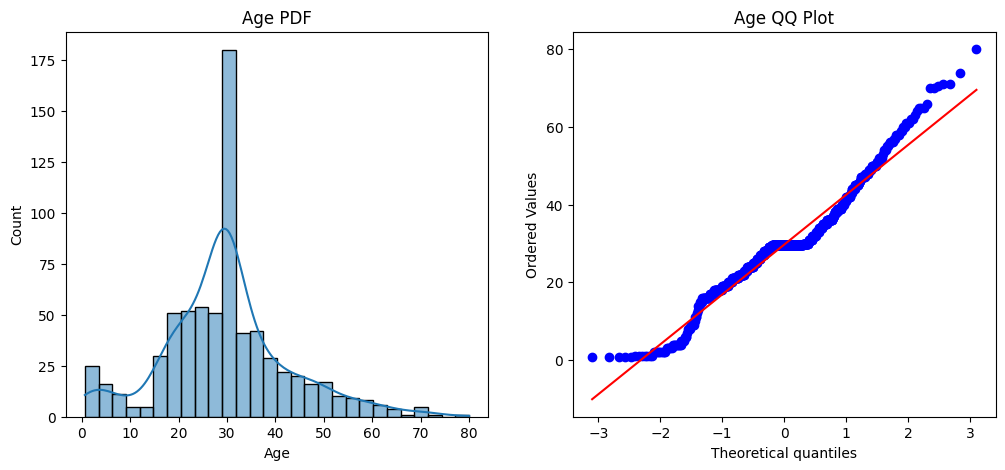

In [47]:
plt.figure(figsize=(12,5))
plt.subplot(121)  # plt.subplot(nrows, ncols, index)
sns.histplot(x_train["Age"], kde=True)
plt.title('Age PDF')

plt.subplot(122) 
stats.probplot(x_train['Age'],dist='norm',plot=plt)
plt.title('Age QQ Plot')

plt.show()

In [48]:
## Show above both figure age data is almost normally distributed so there is no need to funciotn transformation but 
## chek how many accurcy imrove after function transformation

## Showing Distribution of Fare data

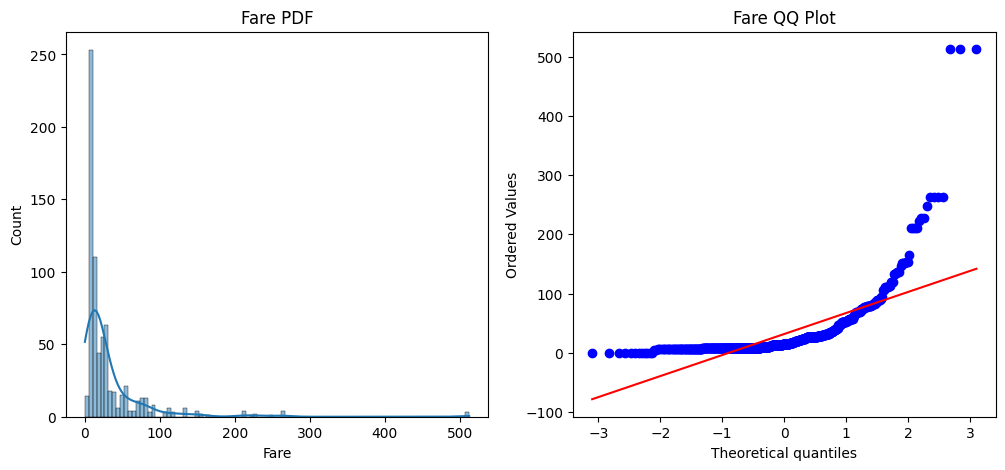

In [49]:
plt.figure(figsize=(12,5))

plt.subplot(121)
sns.histplot(x_train['Fare'],kde=True)
plt.title("Fare PDF")

plt.subplot(122)
stats.probplot(x_train['Fare'],dist='norm',plot=plt)
plt.title("Fare QQ Plot")

plt.show()

In [50]:
## Show Above fig we can say that given fare columns is right skwed so apply log transformation on fare

In [51]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

## Cheking Accurecy Before Function Transformation

In [52]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [56]:
clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)

y_pred=clf.predict(x_test)
y_pred1=clf2.predict(x_test)

print("Accurecy LR",accuracy_score(y_test,y_pred))
print("Accurecy DT",accuracy_score(y_test,y_pred1))

Accurecy LR 0.6983240223463687
Accurecy DT 0.6815642458100558


## Cheking Accurecy After Funcion Transformation

In [57]:
trf=FunctionTransformer(np.log1p)

In [58]:
x_train_transformed=trf.fit_transform(x_train)
x_test_transformed=trf.fit_transform(x_test)

In [61]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

clf.fit(x_train_transformed,y_train)
clf2.fit(x_train_transformed,y_train)

y_pred=clf.predict(x_test_transformed)
y_pred1=clf2.predict(x_test_transformed)

print("Accurecy LR",accuracy_score(y_test,y_pred))
print("Accurecy DT",accuracy_score(y_test,y_pred1))

Accurecy LR 0.7039106145251397
Accurecy DT 0.6703910614525139


## Cross Validation

In [67]:
x_transformed=trf.fit_transform(x)

clf=LogisticRegression()
clf2=DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,x_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,x_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.663383270911361


## Show Fare Distribution Before log Transformation and Agter log Tansformation

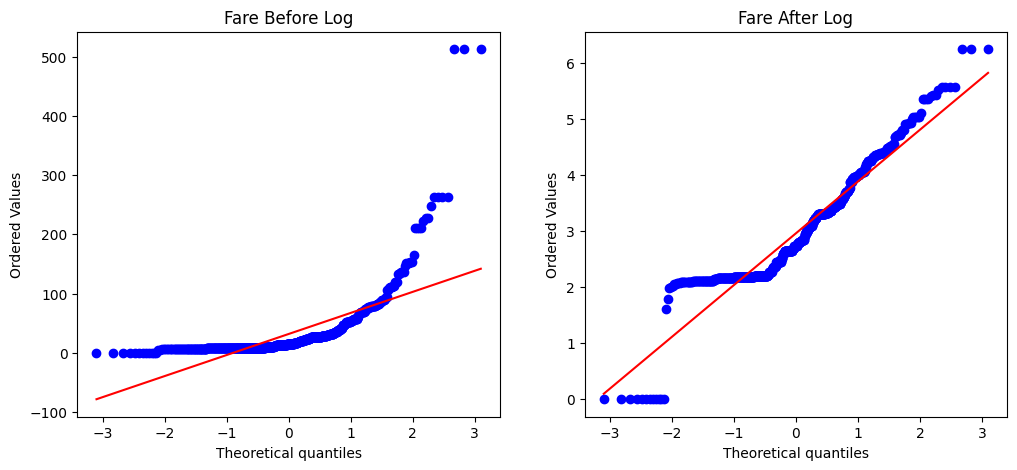

In [70]:
plt.figure(figsize=(12,5))

plt.subplot(121)
stats.probplot(x_train['Fare'],dist='norm',plot=plt)
plt.title("Fare Before Log")

plt.subplot(122)
stats.probplot(x_train_transformed['Fare'],dist='norm',plot=plt)
plt.title("Fare After Log")

plt.show()

## Show Age Distribution Before log transformation and After log transformation

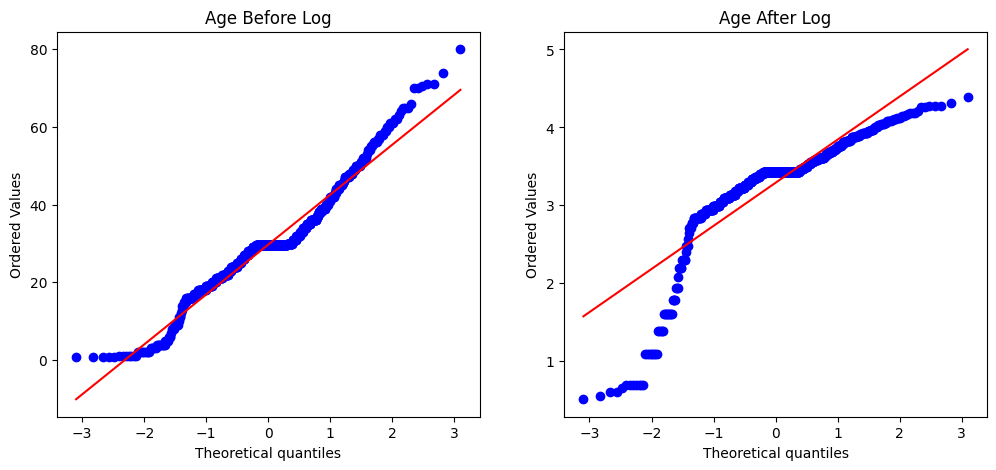

In [68]:
plt.figure(figsize=(12,5))

plt.subplot(121)
stats.probplot(x_train['Age'],dist='norm',plot=plt)
plt.title("Age Before Log")

plt.subplot(122)
stats.probplot(x_train_transformed['Age'],dist='norm',plot=plt)
plt.title("Age After Log")

plt.show()

# Conclusion

#### Observing above four figure you say that Fare column is give some more accurecy in compare to previous one.
#### Where As Age column give less accurecy in compare to previous one.
#### so when right skew data is given then use log transformation other wise not